[Regressão Linear (Baseline)] Concluído. MSE: 0.3900 | R²: 0.4032
[Support Vector Machine (SVM)] Concluído. MSE: 0.3514 | R²: 0.4623
[Rede Neural Artificial (RNA)] Concluído. MSE: 0.4070 | R²: 0.3773


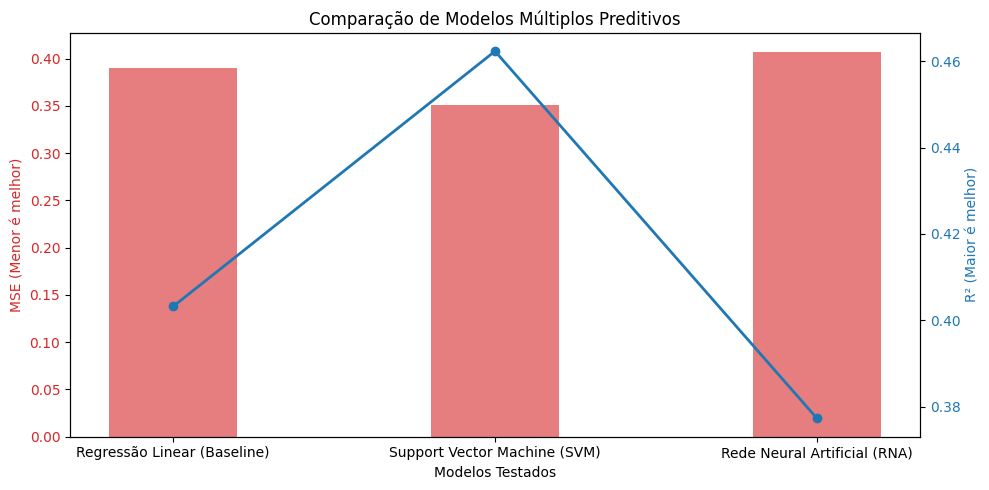

In [2]:
# ==========================================
# COLAB 3: COMPARATIVO DE MODELOS MÚLTIPLOS
# ==========================================

# 1. Importação das Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Carregando os Dados
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
dados = pd.read_csv(url, sep=';')
X = dados.drop(columns=['quality'])
y = dados['quality']

# 3. Divisão e Padronização
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Inicializando os Múltiplos Modelos (RNA ajustada para convergir)
modelos = {
    "Regressão Linear (Baseline)": LinearRegression(),
    "Support Vector Machine (SVM)": SVR(kernel='rbf', C=1.0),
    "Rede Neural Artificial (RNA)": MLPRegressor(hidden_layer_sizes=(64, 32),
                                                max_iter=1000,
                                                learning_rate_init=0.001,
                                                random_state=42)
}

# 5. Loop de Treinamento, Predição e Avaliação
resultados_mse = []
resultados_r2 = []
nomes_modelos = []

for nome, modelo in modelos.items():
    # Treino
    modelo.fit(X_train_scaled, y_train)
    # Predição
    preds = modelo.predict(X_test_scaled)
    # Métricas
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    nomes_modelos.append(nome)
    resultados_mse.append(mse)
    resultados_r2.append(r2)

    print(f"[{nome}] Concluído. MSE: {mse:.4f} | R²: {r2:.4f}")

# 6. Gráfico Comparativo de Desempenho (Múltiplos Modelos) - CORRIGIDO
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfico de Barras para o MSE (Removido o parâmetro inválido 'position')
color = 'tab:red'
ax1.set_xlabel('Modelos Testados')
ax1.set_ylabel('MSE (Menor é melhor)', color=color)
bars = ax1.bar(nomes_modelos, resultados_mse, color=color, alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)

# Criando um segundo eixo para o R²
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R² (Maior é melhor)', color=color)
ax2.plot(nomes_modelos, resultados_r2, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparação de Modelos Múltiplos Preditivos')
fig.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



--- MÊTRICAS DE AVALIAÇÃO (RNA) ---
Erro Quadrático Médio (MSE): 0.4028
Coeficiente de Determinação (R²): 0.3836


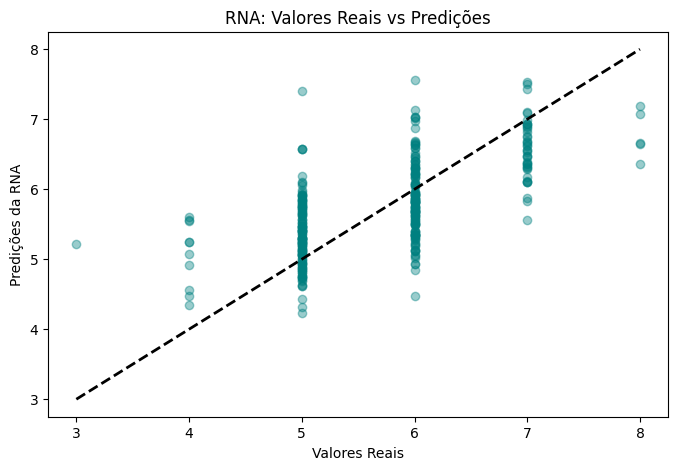

In [4]:
# ==========================================
# COLAB 2: MODELO DE PREDIÇÃO COM RNA (MLP)
# ==========================================

# 1. Importação das Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Carregando a Base de Dados Real
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
dados = pd.read_csv(url, sep=';')

X = dados.drop(columns=['quality'])
y = dados['quality']

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Pré-processamento: Padronização (RNAs são muito sensíveis à escala dos dados)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treinamento da Rede Neural (RNA)
# Criando uma rede com 2 camadas ocultas (com 64 e 32 neurônios respectivamente)
modelo_rna = MLPRegressor(hidden_layer_sizes=(64, 32),
                          activation='relu',
                          solver='adam',
                          max_iter=500,
                          random_state=42)
modelo_rna.fit(X_train_scaled, y_train)

# 6. Predições e Avaliação
y_pred = modelo_rna.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MÊTRICAS DE AVALIAÇÃO (RNA) ---")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# 7. Gráfico de Resultados
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Predições da RNA')
plt.title('RNA: Valores Reais vs Predições')
plt.show()

--- Primeiras linhas do dataset ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1     

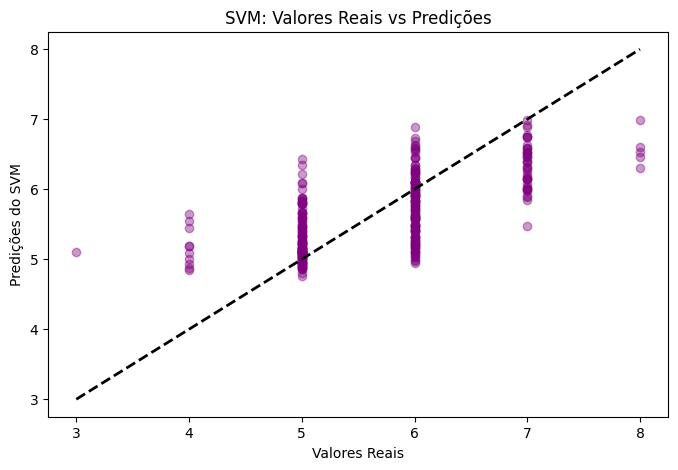

In [3]:
# ==========================================
# COLAB 1: MODELO DE PREDIÇÃO COM SVM (SVR)
# ==========================================

# 1. Importação das Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# 2. Carregando a Base de Dados Real (Wine Quality)
# Usando o dataset de vinho tinto direto da fonte original
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
dados = pd.read_csv(url, sep=';')

print("--- Primeiras linhas do dataset ---")
print(dados.head())

# Separando variáveis preditoras (X) e o alvo (y - qualidade do vinho)
X = dados.drop(columns=['quality'])
y = dados['quality']

# 3. Divisão em Treino e Teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Pré-processamento: Padronização (OBRIGATÓRIA para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Treinamento do Modelo SVM (Regressão com kernel RBF)
modelo_svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
modelo_svm.fit(X_train_scaled, y_train)

# 6. Predições e Avaliação
y_pred = modelo_svm.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MÊTRICAS DE AVALIAÇÃO (SVM) ---")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# 7. Gráfico de Resultados: Real vs Predito
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Predições do SVM')
plt.title('SVM: Valores Reais vs Predições')
plt.show()